# OSNet-AIN x1.0 — вариант 2: Optuna, P=16/K=2, BNNeck и SupCon

Этот notebook создаёт **новый development-эксперимент**, не изменяя вариант 1 и активный MVP.

Порядок работы:

1. smoke test новой модели и loss;
2. 16 Optuna trials по 8 эпох на внутреннем разбиении;
3. ранняя остановка слабых trials не раньше четвёртой эпохи;
4. продолжение четырёх лучших конфигураций до 20 эпох;
5. независимое обучение двух финалистов до 30 эпох с тремя seed;
6. выбор по среднему inner-validation mAP и обучение победителя на всех 925 train identity;
7. оценка на прежних calibration/validation и сохранение важных checkpoint/ONNX.

`test_query.csv` и `test_gallery.csv` не используются при обучении, HPO или выборе checkpoint.

## 1. Окружение

Из корня репозитория:

```bash
uv pip install --python .venv/bin/python -r requirements-train.txt
uv pip check --python .venv/bin/python
.venv/bin/python -m jupyter lab
```

Один trial ограничен 8 эпохами. Median pruner может остановить слабый запуск только после четвёртой эпохи. Затем top-4 продолжаются до 20 эпох, а top-2 проверяются с тремя seed по 30 эпох. На MPS полный `Run All` займёт несколько часов.

In [11]:
import gc
import json
import os
import sys
from dataclasses import asdict
from pathlib import Path

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'backend').exists():
    ROOT = ROOT.parent
assert (ROOT / 'backend').exists(), 'Не найден корень Car-classification-MSK'
os.chdir(ROOT)

import matplotlib.pyplot as plt
import numpy as np
import onnxruntime as ort
import torch
from PIL import Image
from torch.nn import functional as F

from backend.core import DATASET, STOCK_MODEL, bbox, preprocess, sha256
from backend.evaluate import write_json
from training.hpo import (
    ExperimentConfig, config_from_trial, continue_top_candidates, experiment_losses, fit_selected,
    initialize_experiment, load_hpo_study, make_optimizer, prepare_experiment,
    run_finalist_seeds, run_hpo, set_epoch_learning_rates, split_hpo_identities,
)
from training.osnet import export_encoder_onnx
from training.pipeline import ensure_splits, select_device, set_seed, split_summary

VARIANT_DIR = ROOT / 'OSNet-AIN-x1.0/variant_02_hpo_bnneck_supcon'
WEIGHTS_DIR = VARIANT_DIR / 'weights'
RESULTS_DIR = VARIANT_DIR / 'results'
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

TARGET_TRIALS = 16
TRIAL_EPOCHS = 8
TOP_CANDIDATES = 4
PROMOTION_EPOCHS = 20
FINALISTS = 2
FINALIST_EPOCHS = 30
FINALIST_SEEDS = (20260915, 20260916, 20260917)
OUTER_EPOCHS = 30
RUN_HPO = True
RUN_STAGE2 = True
RUN_STAGE3 = True
RUN_SELECTED_TRAINING = True
RUN_EXPORT = True
RUN_NAME = 'selected_run_02'  # Измените имя перед новым независимым полным запуском.

SELECTED_WEIGHTS = WEIGHTS_DIR / RUN_NAME
SELECTED_RESULTS = RESULTS_DIR / RUN_NAME
DEVICE = select_device()
set_seed(20260915)
print('python:', sys.executable)
print('device:', DEVICE, '| torch:', torch.__version__)
print('variant:', VARIANT_DIR)

python: /Users/elvsevolod/Desktop/учеба/Учёба 4 курс/Хакатон мск сентябрь/Car-classification-MSK/.venv/bin/python
device: mps | torch: 2.14.0
variant: /Users/elvsevolod/Desktop/учеба/Учёба 4 курс/Хакатон мск сентябрь/Car-classification-MSK/OSNet-AIN-x1.0/variant_02_hpo_bnneck_supcon


## 2. Разбиения без утечки

Внешнее разбиение остаётся тем же, что в варианте 1: 925 train, 307 calibration и 309 validation identity.

Для Optuna 925 train identity дополнительно делятся на:

- 80% HPO-train;
- 20% HPO-validation.

Внешние calibration и validation не участвуют в поиске гиперпараметров. Они используются только после завершения HPO для выбранной конфигурации.

In [12]:
rows, split = ensure_splits(DATASET)
print(json.dumps(split_summary(rows, split), ensure_ascii=False, indent=2))
hpo_train_ids, hpo_validation_ids = split_hpo_identities(split['identities']['train'])
print('HPO train identities:', len(hpo_train_ids))
print('HPO validation identities:', len(hpo_validation_ids))
assert set(hpo_train_ids).isdisjoint(hpo_validation_ids)
assert set(hpo_train_ids + hpo_validation_ids) == set(split['identities']['train'])

{
  "train": {
    "identities": 925,
    "images": 5717
  },
  "calibration": {
    "identities": 307,
    "images": 1903
  },
  "validation": {
    "identities": 309,
    "images": 1936
  }
}
HPO train identities: 740
HPO validation identities: 185


## 3. Smoke test: P=16/K=2, разные камеры, BNNeck и SupCon

Вариант 2 использует 16 identity по 2 изображения. Это даёт каждому anchor 15 negative identity вместо 7 в варианте 1. Sampler по возможности берёт два positive с разных камер. `camera_id` используется только для формирования train-batch и не подаётся модели.

Encoder и случайно созданная голова обучаются с разными learning rate. BNNeck и тип metric loss затем выбирает Optuna.

In [13]:
SMOKE_CONFIG = ExperimentConfig(epochs=1, identities_per_batch=16, images_per_identity=2,
                                metric_loss='supcon', use_bnneck=True)
smoke_rows, smoke_labels, smoke_sampler, smoke_loader = prepare_experiment(
    rows, hpo_train_ids, SMOKE_CONFIG, DATASET
)
indices = next(iter(smoke_sampler))
for label in {smoke_rows[index]['label'] for index in indices}:
    selected = [smoke_rows[index] for index in indices if smoke_rows[index]['label'] == label]
    assert len(selected) == 2
    assert len({item['camera_id'] for item in selected}) == 2

clean, robust, labels, _ = next(iter(smoke_loader))
assert clean.shape == robust.shape == (32, 3, 208, 208)
assert len(set(labels.tolist())) == 16
assert all(labels.tolist().count(label) == 2 for label in set(labels.tolist()))

smoke_model, loaded_tensors = initialize_experiment(len(smoke_labels), SMOKE_CONFIG, DEVICE, STOCK_MODEL)
smoke_optimizer = make_optimizer(smoke_model, SMOKE_CONFIG)
lrs = set_epoch_learning_rates(smoke_optimizer, SMOKE_CONFIG, 0, 1)
smoke_optimizer.zero_grad(set_to_none=True)
losses = experiment_losses(smoke_model, clean.to(DEVICE), robust.to(DEVICE), labels.to(DEVICE), SMOKE_CONFIG)
losses['loss'].backward()
smoke_optimizer.step()
assert all(torch.isfinite(value) for value in losses.values())
print('loaded stock tensors:', loaded_tensors)
print('learning rates:', lrs)
print({name: round(float(value.detach()), 6) for name, value in losses.items()})

del smoke_model, smoke_optimizer, smoke_loader, clean, robust, labels, losses
gc.collect()
if DEVICE.type == 'mps': torch.mps.empty_cache()
if DEVICE.type == 'cuda': torch.cuda.empty_cache()

loaded stock tensors: 559
learning rates: {'encoder': 5e-05, 'head': 0.0005}
{'loss': 7.770576, 'classification': 6.632901, 'metric': 1.112566, 'consistency': 0.251083, 'accuracy': 0.0}


## 4. Optuna HPO — 16 trials

Поиск фиксирует `P=16, K=2` и перебирает:

- Triplet или Supervised Contrastive loss;
- BNNeck включён/выключен;
- encoder LR `5e-5 … 3e-4`;
- множитель LR головы `5` или `10`;
- weight decay `1e-5 … 1e-3`;
- вес metric loss;
- triplet margin, если выбран Triplet;
- вес consistency loss.

Study хранится в `results/optuna.sqlite3`. Повторный запуск продолжает study только до общего числа `TARGET_TRIALS`, а не добавляет ещё 16. Слабый trial разрешено прервать только после четырёх законченных эпох.

In [14]:
if RUN_HPO:
    study = run_hpo(rows, split, DEVICE, RESULTS_DIR, WEIGHTS_DIR,
                    target_trials=TARGET_TRIALS, trial_epochs=TRIAL_EPOCHS, dataset=DATASET)
else:
    study = load_hpo_study(RESULTS_DIR)

print('best trial:', study.best_trial.number)
print('inner-validation mAP:', study.best_value)
print(json.dumps(study.best_trial.params, ensure_ascii=False, indent=2))

[I 2026-09-16 17:35:38,254] A new study created in RDB with name: osnet_ain_x1_0_variant_02


epoch 1:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 1/8 | осталось эпох: 7 | эпоха: 00:00:47 | прошло: 00:00:47 | ETA: 00:05:26 | best mAP: 0.7769


epoch 2:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 2/8 | осталось эпох: 6 | эпоха: 00:00:46 | прошло: 00:01:33 | ETA: 00:04:38 | best mAP: 0.7769


...

Epoch 7/8 | осталось эпох: 1 | эпоха: 00:00:48 | прошло: 00:05:38 | ETA: 00:00:48 | best mAP: 0.8074


epoch 8:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 8/8 | осталось эпох: 0 | эпоха: 00:00:48 | прошло: 00:06:26 | ETA: 00:00:00 | best mAP: 0.8092


[I 2026-09-16 19:00:20,925] Trial 15 finished with value: 0.8091650021708051 and parameters: {'metric_loss': 'supcon', 'encoder_lr': 9.605092035663954e-05, 'head_lr_multiplier': 10.0, 'weight_decay': 0.0009707380913239312, 'metric_weight': 1.4860094927422844, 'consistency_weight': 0.20578953780397646, 'use_bnneck': True}. Best is trial 5 with value: 0.812993763612363.


best trial: 5
inner-validation mAP: 0.812993763612363
{
  "metric_loss": "supcon",
  "encoder_lr": 0.00011940564013110387,
  "head_lr_multiplier": 10.0,
  "weight_decay": 6.069870050850335e-05,
  "metric_weight": 1.4948762510958067,
  "consistency_weight": 0.22571745222502657,
  "use_bnneck": true
}


In [15]:
completed = [trial for trial in study.trials if trial.value is not None]
completed = sorted(completed, key=lambda trial: trial.value, reverse=True)
for trial in completed[:10]:
    print(f"trial={trial.number:02d} | state={trial.state.name:8s} | mAP={trial.value:.4f} | "
          f"metric={trial.params.get('metric_loss')} | bnneck={trial.params.get('use_bnneck')} | "
          f"lr={trial.params.get('encoder_lr'):.2e}")

if RUN_STAGE2:
    stage2_summary = continue_top_candidates(
        rows, split, study, DEVICE, RESULTS_DIR, WEIGHTS_DIR,
        top_k=TOP_CANDIDATES, target_epochs=PROMOTION_EPOCHS, dataset=DATASET,
    )
else:
    stage2_summary = json.loads((RESULTS_DIR / 'stage2_top4_summary.json').read_text())
print('top-4 after 20 epochs:', [(item['trial_number'], round(item['best_mAP'], 4))
                                    for item in stage2_summary['candidates']])

if RUN_STAGE3:
    stage3_summary = run_finalist_seeds(
        rows, split, study, stage2_summary, DEVICE, RESULTS_DIR, WEIGHTS_DIR,
        top_k=FINALISTS, target_epochs=FINALIST_EPOCHS, seeds=FINALIST_SEEDS, dataset=DATASET,
    )
else:
    stage3_summary = json.loads((RESULTS_DIR / 'stage3_top2_seeds_summary.json').read_text())
winner_number = stage3_summary['best_trial_number']
winner_trial = next(trial for trial in study.trials if trial.number == winner_number)
print('winner trial by mean seed mAP:', winner_number)
print(json.dumps(stage3_summary['finalists'], ensure_ascii=False, indent=2))

trial=05 | state=COMPLETE | mAP=0.8130 | metric=supcon | bnneck=True | lr=1.19e-04
trial=12 | state=COMPLETE | mAP=0.8106 | metric=supcon | bnneck=True | lr=9.81e-05
trial=15 | state=COMPLETE | mAP=0.8092 | metric=supcon | bnneck=True | lr=9.61e-05
trial=08 | state=COMPLETE | mAP=0.8080 | metric=triplet | bnneck=True | lr=8.12e-05
trial=01 | state=COMPLETE | mAP=0.8079 | metric=triplet | bnneck=True | lr=1.93e-04
trial=11 | state=COMPLETE | mAP=0.8076 | metric=supcon | bnneck=True | lr=1.02e-04
trial=07 | state=COMPLETE | mAP=0.8052 | metric=triplet | bnneck=True | lr=7.69e-05
trial=00 | state=COMPLETE | mAP=0.7995 | metric=triplet | bnneck=False | lr=1.47e-04
trial=14 | state=PRUNED   | mAP=0.7989 | metric=supcon | bnneck=True | lr=1.24e-04
trial=02 | state=COMPLETE | mAP=0.7987 | metric=triplet | bnneck=True | lr=6.74e-05


epoch 9:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 9/20 | осталось эпох: 11 | эпоха: 00:00:51 | прошло: 00:00:51 | ETA: 00:09:22 | best mAP: 0.8130


epoch 10:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 10/20 | осталось эпох: 10 | эпоха: 00:00:51 | прошло: 00:01:42 | ETA: 00:08:32 | best mAP: 0.8182


...

Epoch 28/30 | осталось эпох: 2 | эпоха: 00:00:46 | прошло: 00:21:43 | ETA: 00:01:33 | best mAP: 0.8477


epoch 29:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 29/30 | осталось эпох: 1 | эпоха: 00:00:46 | прошло: 00:22:29 | ETA: 00:00:47 | best mAP: 0.8477


epoch 30:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 30/30 | осталось эпох: 0 | эпоха: 00:00:46 | прошло: 00:23:16 | ETA: 00:00:00 | best mAP: 0.8477
winner trial by mean seed mAP: 5
[
  {
    "trial_number": 5,
    "stage2_mAP": 0.821311750886527,
    "mean_best_mAP": 0.8461672418154973,
    "std_best_mAP": 0.014759102153396255,
    "runs": [
      {
        "seed": 20260915,
        "config": {
          "epochs": 30,
          "identities_per_batch": 16,
          "images_per_identity": 2,
          "encoder_lr": 0.00011940564013110387,
          "head_lr_multiplier": 10.0,
          "weight_decay": 6.069870050850335e-05,
          "warmup_epochs": 2,
          "min_lr_ratio": 0.02,
          "metric_loss": "supcon",
          "metric_weight": 1.4948762510958067,
          "triplet_margin": 0.5,
          "supcon_temperature": 0.1,
          "consistency_weight": 0.22571745222502657,
          "label_smoothing": 0.1,
          "use_bnneck": true,
          "prefer_cross_camera": true,
          "num_workers": 0,
          "seed"

## 5. Полное development-обучение победившей конфигурации

Победитель выбирается по среднему лучшему mAP на трёх seed. После этого конфигурация заново инициализируется из стокового ONNX и обучается на всех 925 train identity 30 эпох. Внешние calibration/validation впервые используются только здесь.

Checkpoint policy:

- `last.pt` обновляется после каждой завершённой эпохи;
- `best_map.pt`, `best_f1.pt`, `best_tnr.pt` хранят лидеров отдельных метрик;
- `epoch_XX.pt` сохраняется один раз, если эпоха улучшила хотя бы одну из этих метрик;
- `checkpoint_index.json` связывает метрику с номером эпохи.

Так mAP и качество отказа больше не смешиваются в один неявный критерий.

In [16]:
SELECTED_CONFIG = config_from_trial(winner_trial, epochs=OUTER_EPOCHS, seed=FINALIST_SEEDS[0])
print(json.dumps(asdict(SELECTED_CONFIG), ensure_ascii=False, indent=2))
write_json(RESULTS_DIR / 'selected_config.json', asdict(SELECTED_CONFIG))

if RUN_SELECTED_TRAINING:
    assert not (SELECTED_RESULTS / 'history.json').exists(), (
        f'{RUN_NAME} уже содержит history.json. Измените RUN_NAME, чтобы не перезаписать эксперимент.'
    )
    set_seed(SELECTED_CONFIG.seed)
    selected_rows, selected_labels, selected_sampler, selected_loader = prepare_experiment(
        rows, split['identities']['train'], SELECTED_CONFIG, DATASET
    )
    selected_model, loaded_tensors = initialize_experiment(
        len(selected_labels), SELECTED_CONFIG, DEVICE, STOCK_MODEL
    )
    history, checkpoint_index = fit_selected(
        selected_model, rows, split, selected_loader, selected_sampler, DEVICE,
        SELECTED_CONFIG, SELECTED_WEIGHTS, SELECTED_RESULTS,
    )
else:
    history_path = SELECTED_RESULTS / 'history.json'
    history = json.loads(history_path.read_text()) if history_path.exists() else []
    checkpoint_index_path = SELECTED_RESULTS / 'checkpoint_index.json'
    checkpoint_index = json.loads(checkpoint_index_path.read_text()) if checkpoint_index_path.exists() else None
    print('Полное обучение выключено; загружены существующие результаты:', bool(history))

{
  "epochs": 30,
  "identities_per_batch": 16,
  "images_per_identity": 2,
  "encoder_lr": 0.00011940564013110387,
  "head_lr_multiplier": 10.0,
  "weight_decay": 6.069870050850335e-05,
  "warmup_epochs": 2,
  "min_lr_ratio": 0.02,
  "metric_loss": "supcon",
  "metric_weight": 1.4948762510958067,
  "triplet_margin": 0.5,
  "supcon_temperature": 0.1,
  "consistency_weight": 0.22571745222502657,
  "label_smoothing": 0.1,
  "use_bnneck": true,
  "prefer_cross_camera": true,
  "num_workers": 0,
  "seed": 20260915
}


epoch 1:   0%|          | 0/57 [00:00<?, ?it/s]

Epoch 1/30 | осталось эпох: 29 | эпоха: 00:01:20 | прошло: 00:01:20 | ETA: 00:38:41 | best mAP: 0.7644
{
  "epoch": 1,
  "lr": {
    "encoder": 5.9702820065551936e-05,
    "head": 0.0005970282006555193
  },
  "train": {
    "loss": 8.192045261985378,
    "classification": 6.83963670228657,
    "metric": 0.8779670580437309,
    "consistency": 0.17701984053118186,
    "accuracy": 0.0
  },
  "threshold": 0.5564881563186646,
  "calibration": {
    "mAP": 0.7445915685286213,
    "Rank_1": 0.7723577235772358,
    "Rank_5": 0.8739837398373984,
    "mINP": 0.6562177393608083,
    "candidate_precision": 0.5930521091811415,
    "candidate_recall": 0.5340782122905028,
    "candidate_F1": 0.5620223398001176,
    "TNR": 0.6229508196721312,
    "known_queries": 246,
    "unknown_queries": 61,
    "TP": 478,
    "FP": 328,
    "FN": 417,
    "true_refusals": 38
  },
  "validation": {
    "mAP": 0.764395332405812,
    "Rank_1": 0.7530364372469636,
    "Rank_5": 0.8947368421052632,
    "mINP": 0.689740

epoch 2:   0%|          | 0/57 [00:00<?, ?it/s]

Epoch 2/30 | осталось эпох: 28 | эпоха: 00:01:19 | прошло: 00:02:40 | ETA: 00:37:18 | best mAP: 0.7666
{
  "epoch": 2,
  "lr": {
    "encoder": 0.00011940564013110387,
    "head": 0.0011940564013110386
  },
  "train": {
    "loss": 6.824382874003628,
    "classification": 5.981287563056276,
    "metric": 0.542399315457595,
    "consistency": 0.14299060678795764,
    "accuracy": 0.15953947368421054
  },
  "threshold": 0.5245142579078674,
  "calibration": {
    "mAP": 0.7420596717666604,
    "Rank_1": 0.7357723577235772,
    "Rank_5": 0.8780487804878049,
    "mINP": 0.6654482561414882,
    "candidate_precision": 0.510936132983377,
    "candidate_recall": 0.6525139664804469,
    "candidate_F1": 0.5731108930323847,
    "TNR": 0.5081967213114754,
    "known_queries": 246,
    "unknown_queries": 61,
    "TP": 584,
    "FP": 559,
    "FN": 311,
    "true_refusals": 31
  },
  "validation": {
    "mAP": 0.7666167087274559,
    "Rank_1": 0.7489878542510121,
    "Rank_5": 0.902834008097166,
    "

...

Epoch 28/30 | осталось эпох: 2 | эпоха: 00:01:20 | прошло: 00:37:16 | ETA: 00:02:40 | best mAP: 0.8106
{
  "epoch": 28,
  "lr": {
    "encoder": 3.965224099406193e-06,
    "head": 3.9652240994061925e-05
  },
  "train": {
    "loss": 1.2418508195040519,
    "classification": 1.1242882661652147,
    "metric": 0.06418883369157188,
    "consistency": 0.09573112990249667,
    "accuracy": 1.0
  },
  "threshold": 0.5177724361419678,
  "calibration": {
    "mAP": 0.8123361789053735,
    "Rank_1": 0.8252032520325203,
    "Rank_5": 0.926829268292683,
    "mINP": 0.7343554435674274,
    "candidate_precision": 0.6670258620689655,
    "candidate_recall": 0.6916201117318436,
    "candidate_F1": 0.6791003839824465,
    "TNR": 0.6721311475409836,
    "known_queries": 246,
    "unknown_queries": 61,
    "TP": 619,
    "FP": 309,
    "FN": 276,
    "true_refusals": 41
  },
  "validation": {
    "mAP": 0.8065143734804273,
    "Rank_1": 0.7894736842105263,
    "Rank_5": 0.9109311740890689,
    "mINP": 0.7

epoch 29:   0%|          | 0/57 [00:00<?, ?it/s]

Epoch 29/30 | осталось эпох: 1 | эпоха: 00:01:20 | прошло: 00:38:37 | ETA: 00:01:20 | best mAP: 0.8106
{
  "epoch": 29,
  "lr": {
    "encoder": 2.7837281314808773e-06,
    "head": 2.783728131480877e-05
  },
  "train": {
    "loss": 1.2283350312918948,
    "classification": 1.1208413086439435,
    "metric": 0.057514930045918414,
    "consistency": 0.0953227363918957,
    "accuracy": 1.0
  },
  "threshold": 0.5030007362365723,
  "calibration": {
    "mAP": 0.8139268438288138,
    "Rank_1": 0.8292682926829268,
    "Rank_5": 0.9308943089430894,
    "mINP": 0.7336380218394823,
    "candidate_precision": 0.6457711442786069,
    "candidate_recall": 0.7251396648044692,
    "candidate_F1": 0.6831578947368421,
    "TNR": 0.5737704918032787,
    "known_queries": 246,
    "unknown_queries": 61,
    "TP": 649,
    "FP": 356,
    "FN": 246,
    "true_refusals": 35
  },
  "validation": {
    "mAP": 0.8062875502428203,
    "Rank_1": 0.7894736842105263,
    "Rank_5": 0.9149797570850202,
    "mINP": 0.

epoch 30:   0%|          | 0/57 [00:00<?, ?it/s]

Epoch 30/30 | осталось эпох: 0 | эпоха: 00:01:20 | прошло: 00:39:57 | ETA: 00:00:00 | best mAP: 0.8106
{
  "epoch": 30,
  "lr": {
    "encoder": 2.3881128026220776e-06,
    "head": 2.3881128026220773e-05
  },
  "train": {
    "loss": 1.224789481413992,
    "classification": 1.1223836969911007,
    "metric": 0.053867134151228686,
    "consistency": 0.09694017535238936,
    "accuracy": 1.0
  },
  "threshold": 0.5072317123413086,
  "calibration": {
    "mAP": 0.8160549262467742,
    "Rank_1": 0.8373983739837398,
    "Rank_5": 0.926829268292683,
    "mINP": 0.7361961000512443,
    "candidate_precision": 0.6512345679012346,
    "candidate_recall": 0.7072625698324022,
    "candidate_F1": 0.678093197643278,
    "TNR": 0.5901639344262295,
    "known_queries": 246,
    "unknown_queries": 61,
    "TP": 633,
    "FP": 339,
    "FN": 262,
    "true_refusals": 36
  },
  "validation": {
    "mAP": 0.8052257529090399,
    "Rank_1": 0.7935222672064778,
    "Rank_5": 0.9109311740890689,
    "mINP": 0.7

## 6. Графики и отдельный выбор checkpoint

Основной retrieval checkpoint — `best_map.pt`. Для продуктового режима отказа отдельно сравниваются `best_f1.pt` и `best_tnr.pt`; они могут оказаться другими эпохами.

{
  "map": {
    "value": 0.8106164597681462,
    "epoch": 5
  },
  "f1": {
    "value": 0.6549586776859504,
    "epoch": 28
  },
  "tnr": {
    "value": 0.7096774193548387,
    "epoch": 1
  }
}


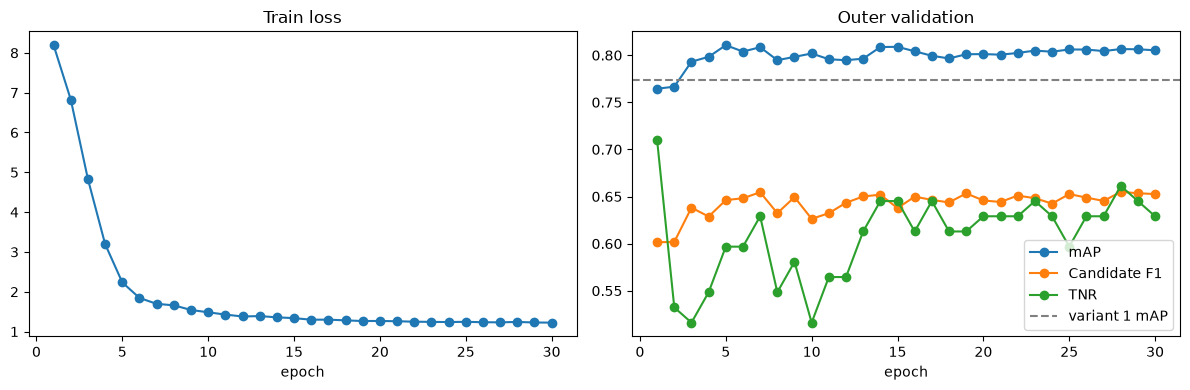

In [17]:
if history:
    epochs = [item['epoch'] for item in history]
    maps = [item['validation']['mAP'] for item in history]
    f1 = [item['validation']['candidate_F1'] for item in history]
    tnr = [item['validation']['TNR'] for item in history]
    losses = [item['train']['loss'] for item in history]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, losses, marker='o'); axes[0].set_title('Train loss'); axes[0].set_xlabel('epoch')
    axes[1].plot(epochs, maps, marker='o', label='mAP')
    axes[1].plot(epochs, f1, marker='o', label='Candidate F1')
    axes[1].plot(epochs, tnr, marker='o', label='TNR')
    axes[1].axhline(.773992168, color='gray', linestyle='--', label='variant 1 mAP')
    axes[1].set_title('Outer validation'); axes[1].set_xlabel('epoch'); axes[1].legend()
    plt.tight_layout()
    print(json.dumps(checkpoint_index, ensure_ascii=False, indent=2))

## 7. Экспорт лучшего mAP-checkpoint в ONNX

Экспорт включает BNNeck, если он выбран Optuna. После экспорта PyTorch и ONNX сравниваются на реальном BBox-кропе. Новый ONNX не подключается к MVP автоматически.

In [18]:
if RUN_EXPORT:
    checkpoint_path = SELECTED_WEIGHTS / 'best_map.pt'
    assert checkpoint_path.exists(), 'Сначала выполните полное development-обучение'
    checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
    export_config = ExperimentConfig(**checkpoint['config'])
    export_model, _ = initialize_experiment(len(split['identities']['train']), export_config, torch.device('cpu'))
    export_model.load_state_dict(checkpoint['model'])
    export_model.eval()

    onnx_path = SELECTED_WEIGHTS / 'osnet_best_map.onnx'
    export_encoder_onnx(export_model.inference_module(), onnx_path, 'cpu')

    sample = next(row for row in rows if row['vehicle_id'] in set(split['identities']['validation']))
    with Image.open(DATASET / 'images' / f"{sample['image_id']}.jpg") as image:
        array = preprocess(image, bbox(sample))[None]
    with torch.inference_mode():
        pytorch_output = export_model.embedding(torch.from_numpy(array)).numpy()
    session = ort.InferenceSession(str(onnx_path), providers=['CPUExecutionProvider'])
    onnx_output = session.run(['output'], {session.get_inputs()[0].name: array})[0]
    max_difference = float(np.max(np.abs(pytorch_output - onnx_output)))
    cosine = float(F.cosine_similarity(torch.from_numpy(pytorch_output), torch.from_numpy(onnx_output)).item())
    parity = {'max_absolute_difference': max_difference, 'cosine_similarity': cosine}
    assert cosine > .99999 and max_difference < 1e-3, parity

    summary = {
        'run_name': RUN_NAME,
        'checkpoint': checkpoint_path.name,
        'checkpoint_epoch': checkpoint['epoch'],
        'config': checkpoint['config'],
        'threshold': checkpoint['threshold'],
        'calibration': checkpoint['calibration'],
        'validation': checkpoint['validation'],
        'onnx': str(onnx_path.relative_to(ROOT)),
        'onnx_sha256': sha256(onnx_path),
        'parity': parity,
    }
    write_json(SELECTED_RESULTS / 'summary.json', summary)
    print(json.dumps(summary, ensure_ascii=False, indent=2))

{
  "run_name": "selected_run_02",
  "checkpoint": "best_map.pt",
  "checkpoint_epoch": 5,
  "config": {
    "epochs": 30,
    "identities_per_batch": 16,
    "images_per_identity": 2,
    "encoder_lr": 0.00011940564013110387,
    "head_lr_multiplier": 10.0,
    "weight_decay": 6.069870050850335e-05,
    "warmup_epochs": 2,
    "min_lr_ratio": 0.02,
    "metric_loss": "supcon",
    "metric_weight": 1.4948762510958067,
    "triplet_margin": 0.5,
    "supcon_temperature": 0.1,
    "consistency_weight": 0.22571745222502657,
    "label_smoothing": 0.1,
    "use_bnneck": true,
    "prefer_cross_camera": true,
    "num_workers": 0,
    "seed": 20260915
  },
  "threshold": 0.507683277130127,
  "calibration": {
    "mAP": 0.7788620809284555,
    "Rank_1": 0.7926829268292683,
    "Rank_5": 0.9024390243902439,
    "mINP": 0.7031752419025258,
    "candidate_precision": 0.5927342256214149,
    "candidate_recall": 0.6927374301675978,
    "candidate_F1": 0.6388459556929418,
    "TNR": 0.475409836065

/Users/elvsevolod/Desktop/учеба/Учёба 4 курс/Хакатон мск сентябрь/Car-classification-MSK/.venv/lib/python3.11/site-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset9.py:2855: UserWarning: ONNX export mode is set to TrainingMode.EVAL, but operator 'instance_norm' is set to train=True. Exporting with train=True.
  symbolic_helper.check_training_mode(use_input_stats, "instance_norm")


## 8. Что прислать после обучения

Для анализа достаточно файлов:

- `results/study_summary.json`;
- `results/stage2_top4_summary.json`;
- `results/stage3_top2_seeds_summary.json`;
- `results/selected_config.json`;
- `results/<RUN_NAME>/history.json`;
- `results/<RUN_NAME>/checkpoint_index.json`;
- `results/<RUN_NAME>/summary.json`;
- при необходимости — output ячеек notebook.

После сравнения с вариантом 1 отдельно решим, какой checkpoint подключать к MVP и стоит ли переходить к финальному обучению на train+validation.